In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("stefan.mplstyle")

In [3]:
tyler_wdms = pd.read_csv("../data/tyler/tyler_wdms.csv")
gaiaxp_wdms = pd.read_parquet("../data/ages.pqt")
gaiaxp_wdms = pd.merge(tyler_wdms[["source_id", "phot_g_mean_mag"]],
                       gaiaxp_wdms, left_on="source_id", right_on="sourceid")

In [11]:
len(gaiaxp_wdms)

6041

/tmp/ipykernel_1212/3905566544.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xp_grouped = gaiaxp_wdms.groupby(pd.cut(gaiaxp_wdms["phot_g_mean_mag"], bins))["e_mass_avg"]
/tmp/ipykernel_1212/3905566544.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tyler_grouped = tyler_wdms.groupby(pd.cut(tyler_wdms["phot_g_mean_mag"], bins))["e_mass_avg"]


Text(0, 0.5, '$\\sigma_M$ [$M_\\odot$]')

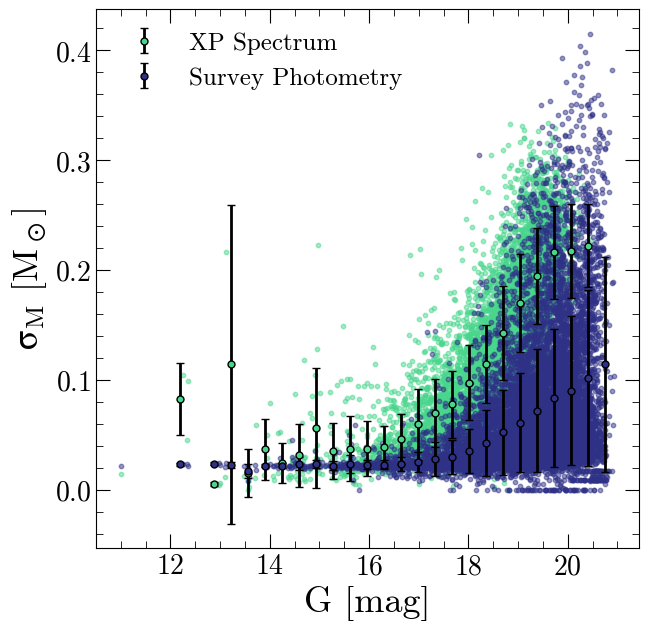

In [5]:
tyler_wdms["e_mass_avg"] =  0.5*(tyler_wdms['e_Mass_upper'] + tyler_wdms["e_Mass_lower"])
gaiaxp_wdms["e_mass_avg"] =  0.5*(gaiaxp_wdms['mass_hi'] - gaiaxp_wdms["mass_lo"])

#2e3186,#ffffe0
plt.scatter(gaiaxp_wdms["phot_g_mean_mag"], gaiaxp_wdms["e_mass_avg"], s=10, alpha=0.5, c="#47d68c")
plt.scatter(tyler_wdms["phot_g_mean_mag"], tyler_wdms["e_mass_avg"], s=10, alpha=0.5, c='#2e3186')

# Binned averages
bins = np.linspace(
    min(gaiaxp_wdms["phot_g_mean_mag"].min(), tyler_wdms["phot_g_mean_mag"].min()),
    max(gaiaxp_wdms["phot_g_mean_mag"].max(), tyler_wdms["phot_g_mean_mag"].max()),
    30
)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

xp_grouped = gaiaxp_wdms.groupby(pd.cut(gaiaxp_wdms["phot_g_mean_mag"], bins))["e_mass_avg"]
xp_mean = xp_grouped.mean()
xp_err = xp_grouped.std()

tyler_grouped = tyler_wdms.groupby(pd.cut(tyler_wdms["phot_g_mean_mag"], bins))["e_mass_avg"]
tyler_mean = tyler_grouped.mean()
tyler_err = tyler_grouped.std()

plt.errorbar(bin_centers, xp_mean.values, yerr=xp_err.values, color="#47d68c", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, label="XP Spectrum")
plt.errorbar(bin_centers, tyler_mean.values, yerr=tyler_err.values, color='#2e3186', 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, label="Survey Photometry")
plt.legend(framealpha=0)

plt.xlabel("G [mag]") ; plt.ylabel("$\\sigma_M$ [$M_\\odot$]")

In [6]:
sdss_rows = (tyler_wdms[["u","g","r","i","z"]] != 0).all(axis=1)
pstr_rows = (tyler_wdms[["g_mean_psf_mag","r_mean_psf_mag","i_mean_psf_mag",
                         "z_mean_psf_mag","y_mean_psf_mag"]] != 0).all(axis=1)
smap_rows = (tyler_wdms[["u_psf","v_psf","g_psf","r_psf","i_psf","z_psf"]] != 0).all(axis=1)

tyler_pstr = tyler_wdms.loc[pstr_rows, :].copy()
tyler_sdss = tyler_wdms.loc[sdss_rows & pstr_rows, :].copy()
tyler_smap = tyler_wdms.loc[sdss_rows & pstr_rows & smap_rows, :].copy()

In [7]:
nicolawds = pd.read_parquet("~/observational/catalogs/nicola_wds/ngf21_wds.pqt")
list(nicolawds.keys())

['recno',
 'WDJname',
 'GaiaEDR3',
 'GaiaDR2',
 'EDR3Name',
 'RA_ICRS',
 'e_RA_ICRS',
 'DE_ICRS',
 'e_DE_ICRS',
 'Plx',
 'e_Plx',
 'RPlx',
 'ZPcor',
 'Pwd',
 'density',
 'SolID',
 'RandomI',
 'Epoch',
 'PM',
 'e_PM',
 'pmRA',
 'e_pmRA',
 'pmDE',
 'e_pmDE',
 'RADEcor',
 'RAPlxcor',
 'RApmRAcor',
 'RApmDEcor',
 'DEPlxcor',
 'DEpmRAcor',
 'DEpmDEcor',
 'PlxpmRAcor',
 'PlxpmDEcor',
 'pmRApmDEcor',
 'NAL',
 'NAC',
 'NgAL',
 'NbAL',
 'gofAL',
 'chi2AL',
 'epsi',
 'sepsi',
 'Solved',
 'APF',
 'nueff',
 'pscol',
 'e_pscol',
 'RApscolCorr',
 'DEpscolCorr',
 'PlxpscolCorr',
 'pmRApscolCorr',
 'pmDEpscolCorr',
 'MatchObsA',
 'Nper',
 'amax',
 'MatchObs',
 'NewMatchObs',
 'MatchObsrm',
 'IPDgofha',
 'IPDgofhp',
 'IPDfmp',
 'IPDfow',
 'RUWE',
 'SDSk1',
 'SDSk2',
 'SDSk3',
 'SDSk4',
 'SDMk1',
 'SDMk2',
 'SDMk3',
 'SDMk4',
 'Dup',
 'o_Gmag',
 'FG',
 'e_FG',
 'RFG',
 'Gmag',
 'e_Gmag',
 'FGCorr',
 'GmagCorr',
 'e_GmagCorr',
 'o_BPmag',
 'FBP',
 'e_FBP',
 'RFBP',
 'BPmag',
 'e_BPmag',
 'o_RPmag',
 'FRP

/tmp/ipykernel_1212/2388989184.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(pd.cut(df[binon], bins))[binto]


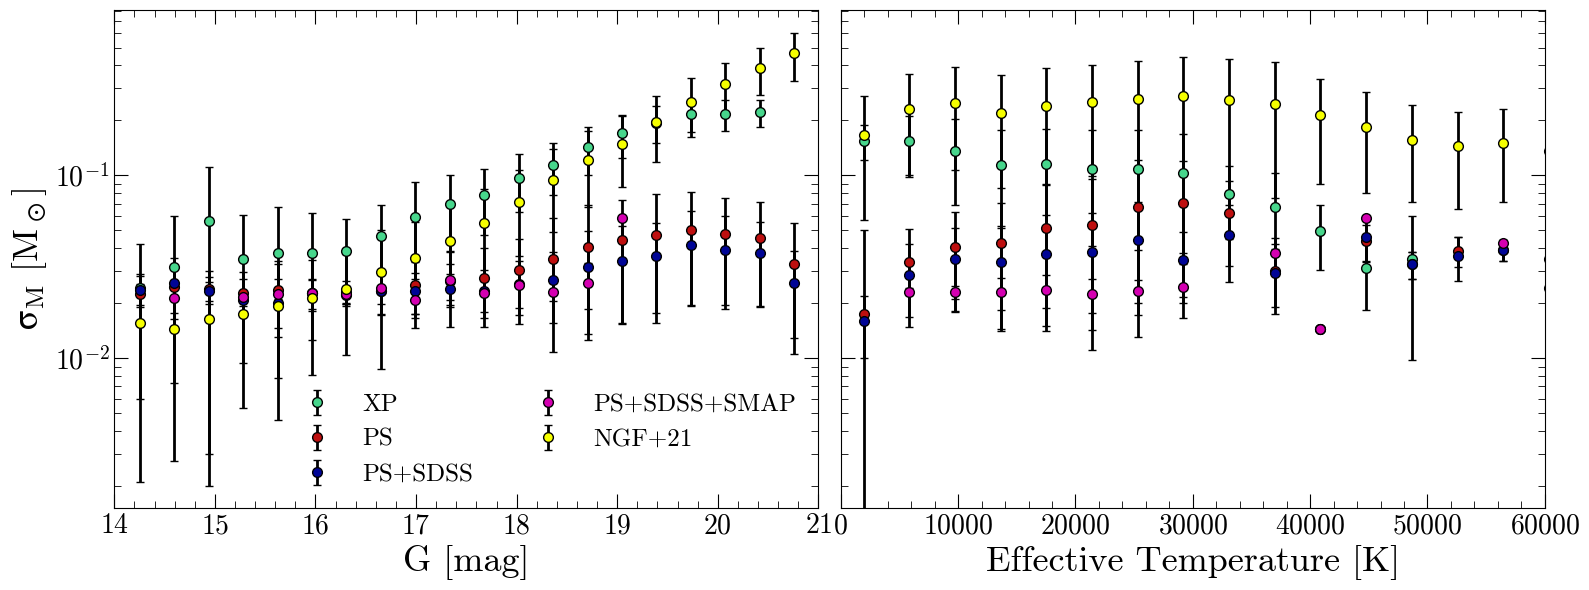

In [10]:
def binit(df: pd.DataFrame, bins: np.array, binon: str = "phot_g_mean_mag", binto: str = "e_mass_avg"):
    df_grouped = df.groupby(pd.cut(df[binon], bins))[binto]
    df_mean = df_grouped.mean()
    df_err = df_grouped.std()
    return df_mean, df_err

fig, ax = plt.subplots(ncols=2, figsize=(16,6), sharey=True)

# Binned averages
brightbins = np.linspace(
    min(gaiaxp_wdms["phot_g_mean_mag"].min(), tyler_wdms["phot_g_mean_mag"].min()),
    max(gaiaxp_wdms["phot_g_mean_mag"].max(), tyler_wdms["phot_g_mean_mag"].max()),
    30
)
brightbin_centers = 0.5 * (brightbins[:-1] + brightbins[1:])

# Binned averages
tempbins = np.linspace(
    min(gaiaxp_wdms["teff_best"].min(), tyler_wdms["Teff"].min()),
    max(gaiaxp_wdms["teff_best"].max(), tyler_wdms["Teff"].max()),
    30
)
tempbin_centers = 0.5 * (tempbins[:-1] + tempbins[1:])

xp_mean_bright, xp_err_bright = binit(gaiaxp_wdms, brightbins)
xp_mean_temper, xp_err_temper = binit(gaiaxp_wdms, tempbins, binon="teff_best")
ax[0].errorbar(brightbin_centers, xp_mean_bright.values, yerr=xp_err_bright.values, color="#47d68c", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="XP")
ax[1].errorbar(tempbin_centers, xp_mean_temper.values, yerr=xp_err_temper.values, color="#47d68c", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="XP")


pstr_mean_bright, pstr_err_bright = binit(tyler_pstr, brightbins)
pstr_mean_temper, pstr_err_temper = binit(tyler_pstr, tempbins, binon="Teff")
ax[0].errorbar(brightbin_centers, pstr_mean_bright.values, yerr=pstr_err_bright.values, color="#be0f0f", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS")
ax[1].errorbar(tempbin_centers, pstr_mean_temper.values, yerr=pstr_err_temper.values, color="#be0f0f", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS")

sdss_mean_bright, sdss_err_bright = binit(tyler_sdss, brightbins)
sdss_mean_temper, sdss_err_temper = binit(tyler_sdss, tempbins, binon="Teff")
ax[0].errorbar(brightbin_centers, sdss_mean_bright.values, yerr=sdss_err_bright.values, color="#000596", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS")
ax[1].errorbar(tempbin_centers, sdss_mean_temper.values, yerr=sdss_err_temper.values, color="#000596", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS")

smap_mean_bright, smap_err_bright = binit(tyler_smap, brightbins)
smap_mean_temper, smap_err_temper = binit(tyler_smap, tempbins, binon="Teff")
ax[0].errorbar(brightbin_centers, smap_mean_bright.values, yerr=smap_err_bright.values, color="#d400b1", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS+SMAP")
ax[1].errorbar(tempbin_centers, smap_mean_temper.values, yerr=smap_err_temper.values, color="#d400b1", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS+SMAP")

ngf_mean_bright, ngf_err_bright = binit(nicolawds, brightbins, binon="GmagCorr", binto="e_MassH")
ngf_mean_temper, ngf_err_temper = binit(nicolawds, tempbins, binon="TeffH", binto="e_MassH")
ax[0].errorbar(brightbin_centers, ngf_mean_bright.values, yerr=ngf_err_bright.values, color="#f6ff00", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="NGF+21")
ax[1].errorbar(tempbin_centers, ngf_mean_temper.values, yerr=ngf_err_temper.values, color="#f6ff00", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="NGF+21")


ax[0].legend(framealpha=0, ncols=2)
ax[0].set_xlim(14, 21) ; ax[1].set_xlim(0, 60000)
ax[0].set_xlabel("G [mag]") ; ax[1].set_xlabel("Effective Temperature [K]")
ax[0].set_ylabel("$\\sigma_M$ [$M_\\odot$]")

ax[0].axhline(y=0, c="k", ls="--") 
ax[1].axhline(y=0, c="k", ls="--")

ax[0].set_yscale("log")

fig.tight_layout()

/tmp/ipykernel_1212/2065653053.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(pd.cut(df[binon], bins))[binto]


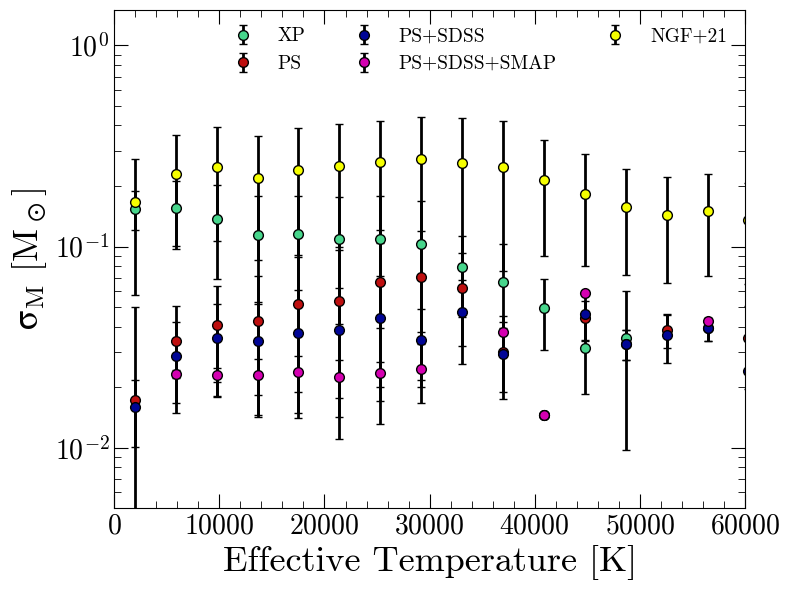

In [22]:
def binit(df: pd.DataFrame, bins: np.array, binon: str = "phot_g_mean_mag", binto: str = "e_mass_avg"):
    df_grouped = df.groupby(pd.cut(df[binon], bins))[binto]
    df_mean = df_grouped.mean()
    df_err = df_grouped.std()
    return df_mean, df_err

fig, ax = plt.subplots(ncols=1, figsize=(8,6), sharey=True)

# Binned averages
tempbins = np.linspace(
    min(gaiaxp_wdms["teff_best"].min(), tyler_wdms["Teff"].min()),
    max(gaiaxp_wdms["teff_best"].max(), tyler_wdms["Teff"].max()),
    30
)
tempbin_centers = 0.5 * (tempbins[:-1] + tempbins[1:])

xp_mean_temper, xp_err_temper = binit(gaiaxp_wdms, tempbins, binon="teff_best")
ax.errorbar(tempbin_centers, xp_mean_temper.values, yerr=xp_err_temper.values, color="#47d68c", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="XP")


pstr_mean_temper, pstr_err_temper = binit(tyler_pstr, tempbins, binon="Teff")
ax.errorbar(tempbin_centers, pstr_mean_temper.values, yerr=pstr_err_temper.values, color="#be0f0f", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS")

sdss_mean_temper, sdss_err_temper = binit(tyler_sdss, tempbins, binon="Teff")
ax.errorbar(tempbin_centers, sdss_mean_temper.values, yerr=sdss_err_temper.values, color="#000596", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS")

smap_mean_temper, smap_err_temper = binit(tyler_smap, tempbins, binon="Teff")
ax.errorbar(tempbin_centers, smap_mean_temper.values, yerr=smap_err_temper.values, color="#d400b1", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="PS+SDSS+SMAP")

ngf_mean_temper, ngf_err_temper = binit(nicolawds, tempbins, binon="TeffH", binto="e_MassH")
ax.errorbar(tempbin_centers, ngf_mean_temper.values, yerr=ngf_err_temper.values, color="#f6ff00", 
             fmt="o", markeredgecolor="k", ecolor="k", lw=2, capsize=3, markersize=7, label="NGF+21")


ax.set_xlim(0, 60000) ; ax.set_ylim(0.5e-2, 1.5)
ax.set_xlabel("Effective Temperature [K]")
ax.set_ylabel("$\\sigma_M$ [$M_\\odot$]")

ax.axhline(y=0, c="k", ls="--") 
ax.axhline(y=0, c="k", ls="--")
ax.legend(framealpha=0, ncols=3, fontsize=14)
ax.set_yscale("log")

fig.tight_layout()
plt.savefig("figures/mass_uncertainty_photometry.pdf")

In [9]:
list(tyler_wdms.keys())

['source_id',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'astrometric_params_solved',
 'ruwe',
 'duplicated_source',
 'phot_g_n_obs',
 'phot_g_mean_flux',
 'phot_g_mean_flux_error',
 'phot_g_mean_flux_over_error',
 'phot_g_mean_mag',
 'phot_bp_n_obs',
 'phot_bp_mean_flux',
 'phot_bp_mean_flux_error',
 'phot_bp_mean_flux_over_error',
 'phot_bp_mean_mag',
 'phot_rp_n_obs',
 'phot_rp_mean_flux',
 'phot_rp_mean_flux_error',
 'phot_rp_mean_flux_over_error',
 'phot_rp_mean_mag',
 'phot_bp_n_contaminated_transits',
 'phot_bp_n_blended_transits',
 'phot_rp_n_contaminated_transits',
 'phot_rp_n_blended_transits',
 'phot_proc_mode',
 'phot_bp_rp_excess_factor',
 'bp_rp',
 'bp_g',
 'g_rp',
 'l',
 'b',
 'ecl_lon',
 'ecl_lat',
 'pairdistance',
 'sep_AU',
 'Sigma18',
 'R_chance_align',
 'meanAV',
 'minAV',
 'maxAV',
 'flag_ext',
 'objid',
 'u',
 'g',
 'r',
 'i',
 'z',
 'err_